# DEC extant species

## Loading data

In [ ]:
### Loading data

In [7]:
# Loading Packages
library("ape")
library("optimx")
library("GenSA")
library("rexpokit")
library("cladoRcpp")
library("snow") 
library("parallel")
library("BioGeoBEARS")
library("palaeoverse")

### Loading Tree

In [16]:
phy = "Orectolobiformes_extant_tree.nex"

### Plotting Tree

In [22]:
tr = read.nexus(phy)
tr = ladderize(tr)

In [60]:
pdf("tree_orectolobiformes.pdf", width = 20, height = 10)
plot(tr, font = 3, cex = 0.75, label.offset = 1.5)
title("Orectolobiformes tree")
axis_geo(intervals = list("epochs", "periods"), phylo = TRUE, skip = c("Holocene", "Late Pleistocene"),height = 0.035, abbr = FALSE)
dev.off()

png 
  2

### Loading presence-absence matrix

In [ ]:
table_geo = "table_geo.txt"

### Loading time period file

In [ ]:
time_period= "time_period.txt"

### Loading connectivity matrix

In [ ]:
connectivity_matrix = "Transition_matrix.txt"

## Setting up DEC

### Intitialize DEC model

In [ ]:
DEC_orectolobiformes = define_BioGeoBEARS_run()

### Setting up DEC input data

#### Phylogeny

In [ ]:
DEC_orectolobiformes$phy = phy

#### Presence-absence matrix

In [ ]:
DEC_orectolobiformes$geogfn = table_geo

#### Tip range

In [ ]:
tipranges = getranges_from_LagrangePHYLIP(lgdata_fn=table_geo)

#### Maximum range size

In [ ]:
max_range_size = 5
DEC_orectolobiformes$max_range_size = max_range_size

#### State list

In [ ]:
areas = getareas_from_tipranges_object(tipranges)
states_area_list = rcpp_areas_list_to_states_list(areas=areas, maxareas=max_range_size, include_null_range=TRUE)
DEC_orectolobiformes$states_list = states_area_list

#### Time periods

In [ ]:
DEC_orectolobiformes$timesfn = time_period

#### Connectivity matrix

In [ ]:
DEC_orectolobiformes$areas_adjacency_fn = connectivity_matrix

#### Forced nodes

In [ ]:
#DEC_orectolobiformes$fixnode = c(43,63,64,75)
#DEC_orectolobiformes$fixlikes = matrix(c(0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,1,0,0,0,1,0,0,1,0,1,1,0,0,1,0,1,1,0,1,1,1,0,0,1,0,1,1,0,1,1,1,0,1,1,1,1,0,1,1,1,1,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,1,1,0,0,0,1,0,0,1,0,1,1,0,0,1,0,1,1,0,1,1,1,0,0,1,0,1,1,0,1,1,1,0,1,1,1,1,0,1,1,1,1,1,0,0,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1),ncol=63,nrow=4,byrow=TRUE)

#### Optimization parameters

In [13]:
DEC_orectolobiformes$force_sparse = FALSE
DEC_orectolobiformes$on_NaN_error = -1e50
DEC_orectolobiformes$speedup = FALSE        
DEC_orectolobiformes$use_optimx = TRUE    
DEC_orectolobiformes$num_cores_to_use = 24

#### Dividing the tree per time periods

In [ ]:
DEC_orectolobiformes = section_the_tree(inputs=DEC_orectolobiformes, make_master_table=TRUE, plot_pieces=FALSE, fossils_older_than=0.001, cut_fossils=FALSE)

#### Ancestral state estimation

In [17]:
DEC_orectolobiformes$return_condlikes_table = TRUE
DEC_orectolobiformes$calc_TTL_loglike_from_condlikes_table = TRUE
DEC_orectolobiformes$calc_ancprobs = TRUE

#### Finalize settings

In [ ]:
DEC_orectolobiformes = readfiles_BioGeoBEARS_run(DEC_orectolobiformes)

### Check inputs

In [16]:
check_BioGeoBEARS_run(DEC_orectolobiformes)

$geogfn
[1] "~/Documents//Stage_M2/Données_R/tableau_cleaned_simple.txt"

$trfn
[1] "~/Documents//Stage_M2/Données_R/tree_orecto.tree"

$abbr
[1] "default"

$description
[1] "defaults"

$BioGeoBEARS_model_object
An object of class "BioGeoBEARS_model"
Slot "params_table":
         type    init      min      max     est                note
d        free 0.01000  1.0e-12  5.00000 0.01000               works
e        free 0.01000  1.0e-12  5.00000 0.01000               works
a       fixed 0.00000  1.0e-12  5.00000 0.00000               works
b       fixed 1.00000  1.0e-12  1.00000 1.00000 non-stratified only
x       fixed 0.00000 -2.5e+00  2.50000 0.00000               works
n       fixed 0.00000 -1.0e+01 10.00000 0.00000               works
w       fixed 1.00000 -1.0e+01 10.00000 1.00000               works
u       fixed 0.00000 -1.0e+01 10.00000 0.00000               works
j       fixed 0.00000  1.0e-05  2.99999 0.00000               works
ysv       3-j 2.99999  1.0e-05  3.00000 2.99999 

An object of class "BioGeoBEARS_model"
Slot "params_table":
         type    init      min      max     est                note
d        free 0.01000  1.0e-12  5.00000 0.01000               works
e        free 0.01000  1.0e-12  5.00000 0.01000               works
a       fixed 0.00000  1.0e-12  5.00000 0.00000               works
b       fixed 1.00000  1.0e-12  1.00000 1.00000 non-stratified only
x       fixed 0.00000 -2.5e+00  2.50000 0.00000               works
n       fixed 0.00000 -1.0e+01 10.00000 0.00000               works
w       fixed 1.00000 -1.0e+01 10.00000 1.00000               works
u       fixed 0.00000 -1.0e+01 10.00000 0.00000               works
j       fixed 0.00000  1.0e-05  2.99999 0.00000               works
ysv       3-j 2.99999  1.0e-05  3.00000 2.99999               works
ys    ysv*2/3 1.99999  1.0e-05  2.00000 1.99999               works
y     ysv*1/3 1.00000  1.0e-05  1.00000 1.00000               works
s     ysv*1/3 1.00000  1.0e-05  1.00000 1.00000         

,type,init,min,max,est,note,desc
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
d,free,0.01000,1.0e-12,5.00000,0.01000,works,anagenesis: rate of 'dispersal' (range expansion)
e,free,0.01000,1.0e-12,5.00000,0.01000,works,anagenesis: rate of 'extinction' (range contraction)
a,fixed,0.00000,1.0e-12,5.00000,0.00000,works,anagenesis: rate of range-switching (i.e. for a standard char.)
b,fixed,1.00000,1.0e-12,1.00000,1.00000,non-stratified only,anagenesis: exponent on branch lengths
x,fixed,0.00000,-2.5e+00,2.50000,0.00000,works,"exponent on distance (modifies d, j, a)"
n,fixed,0.00000,-1.0e+01,10.00000,0.00000,works,"exponent on environmental distance (modifies d, j, a)"
w,fixed,1.00000,-1.0e+01,10.00000,1.00000,works,"exponent on manual dispersal multipliers (modifies d, j, a)"
u,fixed,0.00000,-1.0e+01,10.00000,0.00000,works,anagenesis: exponent on extinction risk with area (modifies e)
j,fixed,0.00000,1.0e-05,2.99999,0.00000,works,cladogenesis: relative per-event weight of jump dispersal


[1] TRUE

## Running the DEC analysis

In [18]:
runslow = TRUE
run_results = "Orecto_DEC.Rdata"
if (runslow){
    res = bears_optim_run(DEC_orectolobiformes)
    res    
    save(res, file=run_results)
    resDEC = res
} else {
    # Loads to "res"
    load(run_results)
    resDEC = res
}


bears_optim_run() note: overall states_list has 63 states/ranges. In stratum #1 (0-1 mya), states_list_for_this_stratum has 63 states/ranges, due to areas_allowed and/or areas_adjacency matrices. See BioGeoBEARS_run_object$lists_of_states_lists_0based.
bears_optim_run() note: overall states_list has 63 states/ranges. In stratum #2 (1-5 mya), states_list_for_this_stratum has 63 states/ranges, due to areas_allowed and/or areas_adjacency matrices. See BioGeoBEARS_run_object$lists_of_states_lists_0based.
bears_optim_run() note: overall states_list has 63 states/ranges. In stratum #3 (5-20 mya), states_list_for_this_stratum has 63 states/ranges, due to areas_allowed and/or areas_adjacency matrices. See BioGeoBEARS_run_object$lists_of_states_lists_0based.
bears_optim_run() note: overall states_list has 63 states/ranges. In stratum #4 (20-40 mya), states_list_for_this_stratum has 63 states/ranges, due to areas_allowed and/or areas_adjacency matrices. See BioGeoBEARS_run_object$lists_of_state

## Plotting Ancestral state estimates

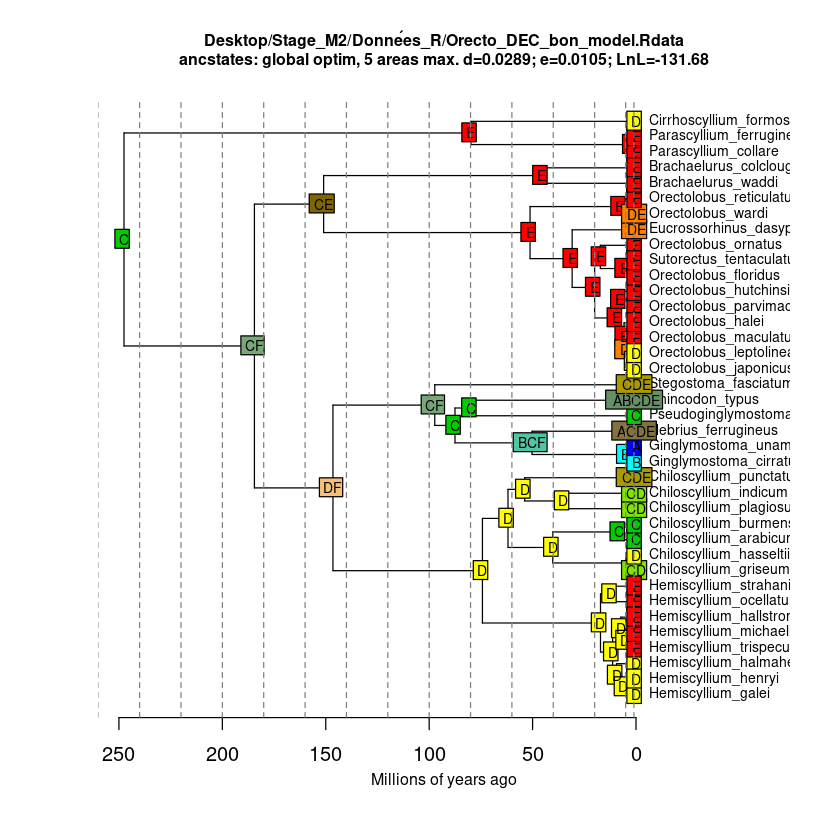

,LnL,nparams,d,e,j
,<list>,<list>,<list>,<list>,<list>
1,-131.6771,2,0.02887298,0.01045535,0


null device 
          1

ERROR: Error in paste("open ", pdffn, sep = ""): objet 'pdffn' introuvable


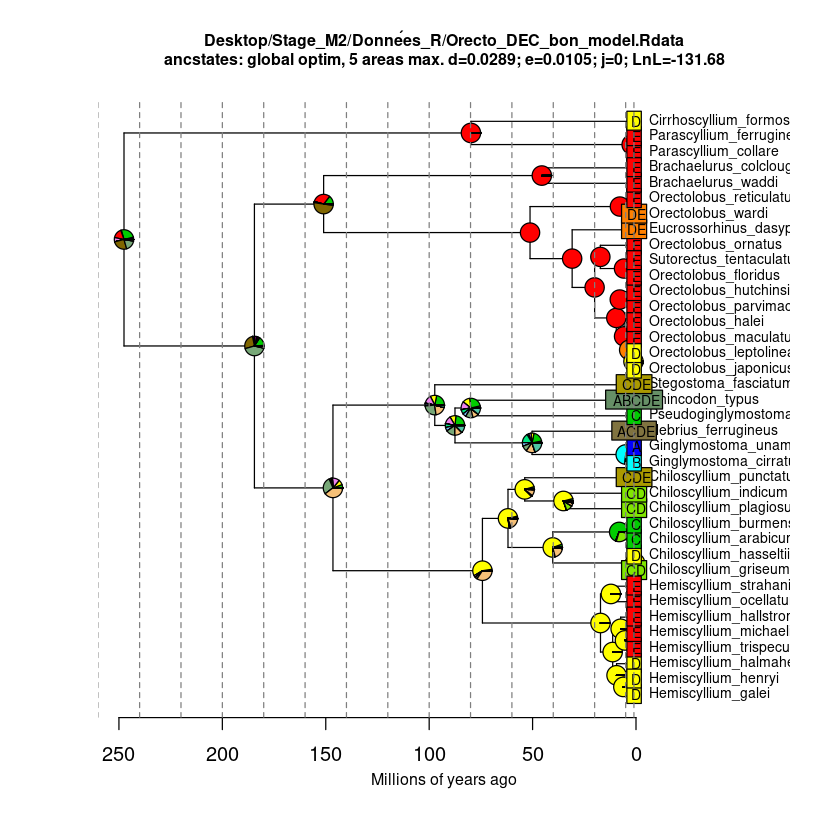

In [19]:
graphical_output ="Orecto_DEC.Rdata"

# Setup
results_object = resDEC
scriptdir = np(system.file("extdata/a_scripts", package="BioGeoBEARS"))

# States
res2 = plot_BioGeoBEARS_results(results_object, graphical_output,  plotwhat="text", label.offset=0.45, tipcex=0.7, statecex=0.7, splitcex=0.6, titlecex=0.8, plotsplits=FALSE, cornercoords_loc=scriptdir, include_null_range=TRUE, tr=tr, tipranges=tipranges)


# Pie chart

plot_BioGeoBEARS_results(results_object, graphical_output, addl_params=list("j"), plotwhat="pie", label.offset=0.45, tipcex=0.7, statecex=0.7, splitcex=0.6, titlecex=0.8, plotsplits=FALSE, cornercoords_loc=scriptdir, include_null_range=TRUE, tr=tr, tipranges=tipranges)


dev.off()  # Turn off PDF

cmdstr = paste("open ", pdffn, sep="")
system(cmdstr) # Plot it